# Финальный проект. Этап 2 — Описательная статистика

**Цель этапа:** получить количественное представление о каждом датасете —
что типично, что является выбросом, как распределены ключевые показатели.

**Данные:** очищенные CSV из `data_clean/` (результат этапа 1).

**План:**
1. Загрузка очищенных данных
2. Числовые переменные: меры центра и разброса
3. Распределения числовых переменных (гистограммы + боксплоты)
4. Категориальные переменные: частотный анализ и столбчатые диаграммы
5. Анализ звонков: длительность и тип
6. Анализ маркетинговых расходов
7. Сводные выводы


## 1. Загрузка очищенных данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Настраиваем стиль графиков — нейтральный и читаемый
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11


In [2]:
# Пути к очищенным файлам (относительно корня проекта)
DATA_CLEAN = '../data_clean/'

# Читаем все четыре датасета
deals = pd.read_csv(DATA_CLEAN + 'deals_clean.csv', low_memory=False)
calls = pd.read_csv(DATA_CLEAN + 'calls_clean.csv', low_memory=False)
contacts = pd.read_csv(DATA_CLEAN + 'contacts_clean.csv', low_memory=False)
spend = pd.read_csv(DATA_CLEAN + 'spend_clean.csv', low_memory=False)

print('Deals:   ', deals.shape)
print('Calls:   ', calls.shape)
print('Contacts:', contacts.shape)
print('Spend:   ', spend.shape)


Deals:    (21593, 26)
Calls:    (95874, 9)
Contacts: (18548, 4)
Spend:    (19862, 8)


In [3]:
# CSV не хранит типы — восстанавливаем после загрузки
deals['Id']           = deals['Id'].astype(str)
deals['Created Time'] = pd.to_datetime(deals['Created Time'])
deals['Closing Date'] = pd.to_datetime(deals['Closing Date'])
for col in ['Quality', 'Stage', 'Source', 'Product', 'Payment Type', 'Education Type', 'Lost Reason']:
    deals[col] = deals[col].astype('category')

calls['Id']             = calls['Id'].astype(str)
calls['Call Start Time'] = pd.to_datetime(calls['Call Start Time'])
for col in ['Call Type', 'Call Status', 'Outgoing Call Status']:
    calls[col] = calls[col].astype('category')

contacts['Id']           = contacts['Id'].astype(str)
contacts['Created Time'] = pd.to_datetime(contacts['Created Time'])
contacts['Modified Time'] = pd.to_datetime(contacts['Modified Time'])

spend['Date']   = pd.to_datetime(spend['Date'])
spend['Source'] = spend['Source'].astype('category')

In [4]:
# Проверяем список колонок каждого датасета
print('=== Deals ===')
print(deals.dtypes)


=== Deals ===
Id                             object
Deal Owner Name                object
Closing Date           datetime64[ns]
Quality                      category
Stage                        category
Lost Reason                  category
Page                           object
Campaign                       object
SLA                            object
Content                        object
Term                           object
Source                       category
Payment Type                 category
Product                      category
Education Type               category
Created Time           datetime64[ns]
Course duration               float64
Months of study               float64
Initial Amount Paid           float64
Offer Total Amount            float64
Contact Name                  float64
City                           object
Level of Deutsch               object
SLA (seconds)                 float64
closing_date_error               bool
amount_error                     boo

In [5]:
print('=== Calls ===')
print(calls.dtypes)


=== Calls ===
Id                                    object
Call Start Time               datetime64[ns]
Call Owner Name                       object
CONTACTID                            float64
Call Type                           category
Call Duration (in seconds)           float64
Call Status                         category
Outgoing Call Status                category
Scheduled in CRM                     float64
dtype: object


In [6]:
print('=== Spend ===')
print(spend.dtypes)


=== Spend ===
Date           datetime64[ns]
Source               category
Campaign               object
Impressions             int64
Spend                 float64
Clicks                  int64
AdGroup                object
Ad                     object
dtype: object


## 2. Числовые переменные: меры центра и разброса

Числовые колонки Deals — те, для которых осмысленно считать среднее и медиану:

- **Initial Amount Paid** — первый платёж студента;
- **Offer Total Amount** — полная стоимость по предложению;
- **SLA (seconds)** — время до первого контакта менеджера;
- **Course duration** — длительность курса в месяцах;
- **Months of study** — сколько месяцев студент уже учится.

Категориальные (Stage, Quality, Source…) и даты разберём отдельно.

In [7]:
# Числовые поля Deals — только те, что несут содержательный смысл
num_deals = ['SLA (seconds)', 'Course duration', 'Months of study',
             'Initial Amount Paid', 'Offer Total Amount']

# describe() даёт сразу count, mean, std, min, квартили, max
deals[num_deals].describe().round(2)

,SLA (seconds),Course duration,Months of study,Initial Amount Paid,Offer Total Amount
count,15533.00,3587.00,840.00,4165.00,4185.00
mean,115826.22,10.20,5.44,950.09,7128.72
std,737252.64,1.83,2.92,1422.15,4636.02
min,3.00,6.00,0.00,0.00,0.00
25%,4380.00,11.00,3.00,300.00,3000.00
50%,19894.00,11.00,5.00,1000.00,11000.00
75%,56318.00,11.00,8.00,1000.00,11000.00
max,26908464.00,11.00,11.00,11500.00,11500.00


In [8]:
# Проверяем, сколько не-NaN значений в каждом поле
# (важно для оценки репрезентативности статистики)
not_null = deals[num_deals].notna().sum()

pct_filled = (not_null / len(deals) * 100).round(1)

summary = pd.DataFrame({'Непустых значений': not_null, '% заполнения': pct_filled})
print(summary)


                     Непустых значений  % заполнения
SLA (seconds)                    15533          71.9
Course duration                   3587          16.6
Months of study                    840           3.9
Initial Amount Paid               4165          19.3
Offer Total Amount                4185          19.4


In [9]:
# Медиана и мода дополняют среднее — полезны при скошенных распределениях
# Рассматриваем ВСЕ числовые столбцы Deals
num_deals = ['SLA (seconds)', 'Course duration', 'Months of study',
             'Initial Amount Paid', 'Offer Total Amount']

stats_rows = {}
for col in num_deals:
    s = deals[col].dropna()
    stats_rows[col] = [s.mean(), s.median(), s.mode()[0], s.std()]

pd.DataFrame(stats_rows, index=['mean', 'median', 'mode', 'std']).round(2)

,SLA (seconds),Course duration,Months of study,Initial Amount Paid,Offer Total Amount
mean,115826.22,10.20,5.44,950.09,7128.72
median,19894.00,11.00,5.00,1000.00,11000.00
mode,611.00,11.00,6.00,1000.00,11000.00
std,737252.64,1.83,2.92,1422.15,4636.02


### Интерпретация: финансовые поля

### SLA (время реакции)

In [10]:
# SLA — время в секундах от создания сделки до первого контакта
# Переводим в часы для удобного чтения
sla = deals['SLA (seconds)'].dropna()

print('SLA (секунды):')
print(f'  Среднее:  {sla.mean():.0f} сек  ({sla.mean()/3600:.1f} ч)')
print(f'  Медиана:  {sla.median():.0f} сек  ({sla.median()/3600:.1f} ч)')
print(f'  Мин:      {sla.min():.0f} сек')
print(f'  Q1:       {sla.quantile(0.25):.0f} сек  ({sla.quantile(0.25)/3600:.1f} ч)')
print(f'  Q3:       {sla.quantile(0.75):.0f} сек  ({sla.quantile(0.75)/3600:.1f} ч)')
print(f'  Макс:     {sla.max():.0f} сек  ({sla.max()/3600:.1f} ч)')


SLA (секунды):
  Среднее:  115826 сек  (32.2 ч)
  Медиана:  19894 сек  (5.5 ч)
  Мин:      3 сек
  Q1:       4380 сек  (1.2 ч)
  Q3:       56318 сек  (15.6 ч)
  Макс:     26908464 сек  (7474.6 ч)


## 3. Распределения числовых переменных

### 3.1 Первый платёж (Initial Amount Paid)

### Выбросы (метод IQR)

Метод IQR: значение считается выбросом, если выходит за Q1 - 1.5*IQR или Q3 + 1.5*IQR. Выбросы не удаляем — фиксируем количество для понимания данных.

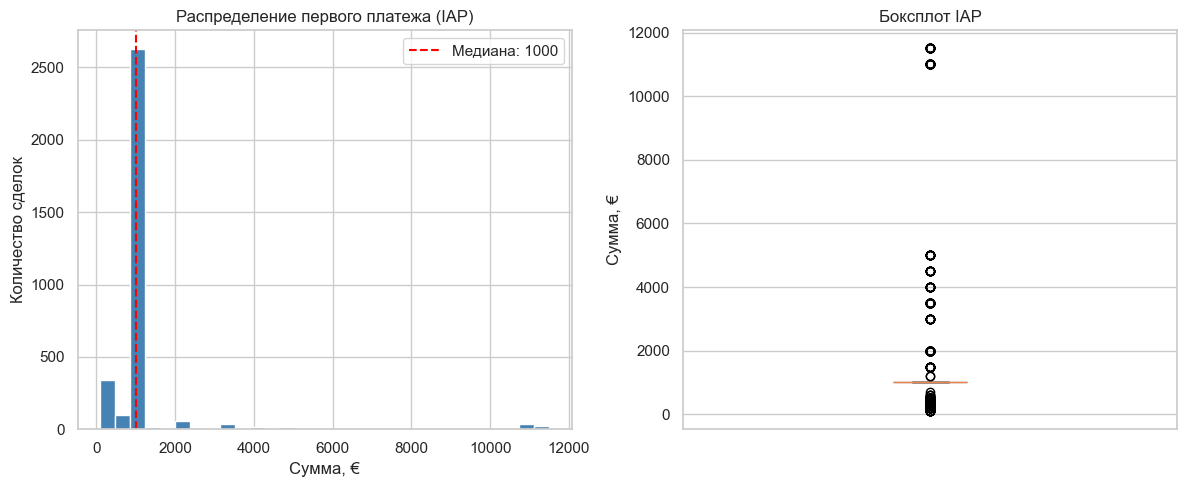

In [11]:
# Оставляем только реальные оплаты: исключаем символические суммы (0, 1, 9 €)
# и строки без суммы
iap_real = deals.loc[
    (~deals['Initial Amount Paid'].isin([0, 1, 9])) & deals['Initial Amount Paid'].notna(),
    'Initial Amount Paid'
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Гистограмма
axes[0].hist(iap_real, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение первого платежа (IAP)')
axes[0].set_xlabel('Сумма, €')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(iap_real.median(), color='red', linestyle='--',
                label=f'Медиана: {iap_real.median():.0f}')
axes[0].legend()

# Боксплот — наглядно показывает выбросы и IQR
axes[1].boxplot(iap_real, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set_title('Боксплот IAP')
axes[1].set_ylabel('Сумма, €')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data_clean/plots/iap_distribution.png', dpi=100)
plt.show()


In [12]:
# Вывод по IAP
q1, q3 = iap_real.quantile(0.25), iap_real.quantile(0.75)
iqr = q3 - q1
outliers_high = iap_real[iap_real > q3 + 1.5 * iqr]
print(f'Количество выбросов (> Q3 + 1.5*IQR = {q3 + 1.5*iqr:.0f}): {len(outliers_high)}')
print(f'Максимальный платёж: {iap_real.max():.0f} €')
print()
print('Вывод: медиана IAP ≈ 1000 €, типичный диапазон 300–1000 €.')
print('Выбросы выше 1500 € — это единичные крупные оплаты (вероятно, полный курс сразу).')


Количество выбросов (> Q3 + 1.5*IQR = 1000): 225
Максимальный платёж: 11500 €

Вывод: медиана IAP ≈ 1000 €, типичный диапазон 300–1000 €.
Выбросы выше 1500 € — это единичные крупные оплаты (вероятно, полный курс сразу).


### 3.2 Полная стоимость (Offer Total Amount)

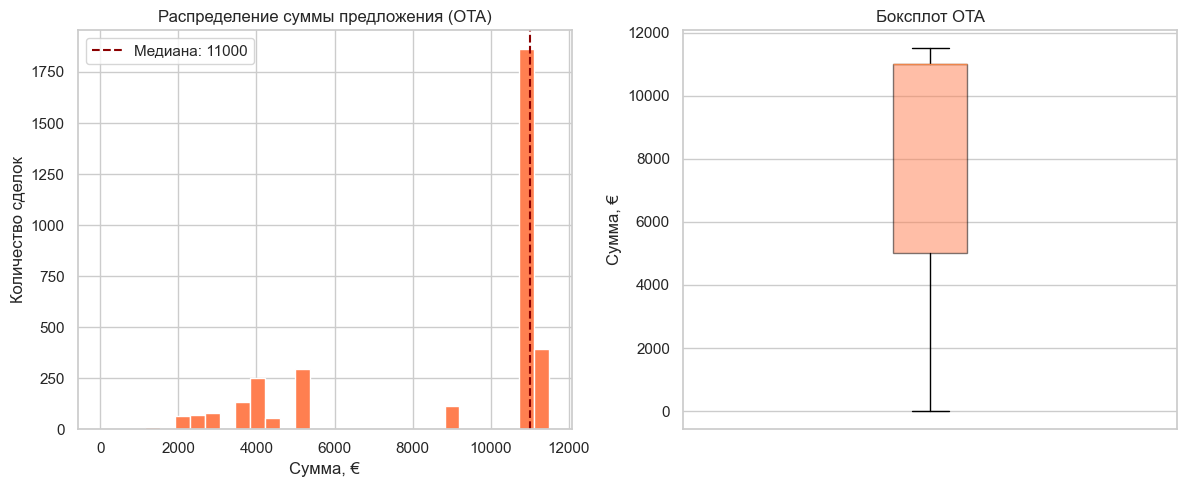

In [13]:
ota_real = deals.loc[
    deals['Offer Total Amount'].notna() & (deals['Offer Total Amount'] > 0),
    'Offer Total Amount'
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(ota_real, bins=30, color='coral', edgecolor='white')
axes[0].set_title('Распределение суммы предложения (OTA)')
axes[0].set_xlabel('Сумма, €')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(ota_real.median(), color='darkred', linestyle='--',
                label=f'Медиана: {ota_real.median():.0f}')
axes[0].legend()

axes[1].boxplot(ota_real, vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.5))
axes[1].set_title('Боксплот OTA')
axes[1].set_ylabel('Сумма, €')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data_clean/plots/ota_distribution.png', dpi=100)
plt.show()


### 3.3 Время реакции — SLA

In [14]:
# Переводим SLA в часы для наглядности
sla_hours = sla / 3600

# Ограничиваем ось X до 72 часов (3 суток) — крайние выбросы искажают график
sla_trimmed = sla_hours[sla_hours <= 72]
print(f'Строк с SLA ≤ 72 ч: {len(sla_trimmed)} из {len(sla_hours)} '
      f'({len(sla_trimmed)/len(sla_hours):.1%})')


Строк с SLA ≤ 72 ч: 14680 из 15533 (94.5%)


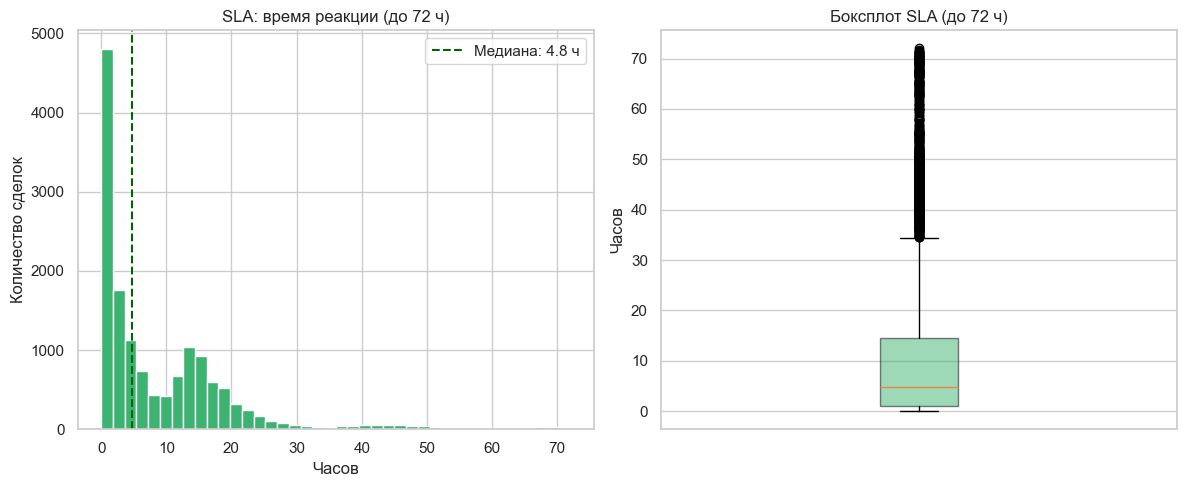

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(sla_trimmed, bins=40, color='mediumseagreen', edgecolor='white')
axes[0].set_title('SLA: время реакции (до 72 ч)')
axes[0].set_xlabel('Часов')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(sla_trimmed.median(), color='darkgreen', linestyle='--',
                label=f'Медиана: {sla_trimmed.median():.1f} ч')
axes[0].legend()

axes[1].boxplot(sla_trimmed, vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.5))
axes[1].set_title('Боксплот SLA (до 72 ч)')
axes[1].set_ylabel('Часов')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data_clean/plots/sla_distribution.png', dpi=100)
plt.show()


In [16]:
# Практический вывод: каков % лидов с быстрым ответом?
fast_response = (sla_hours <= 1).sum()
within_day = (sla_hours <= 24).sum()
total_sla = len(sla_hours)

print(f'Ответ в течение 1 часа:  {fast_response} ({fast_response/total_sla:.1%})')
print(f'Ответ в течение 24 часов: {within_day} ({within_day/total_sla:.1%})')
print()
print('Вывод: быстрый ответ (≤1 ч) — только у части лидов;')
print('большинство ждут более суток, что критично для конверсии.')


Ответ в течение 1 часа:  3472 (22.4%)
Ответ в течение 24 часов: 13672 (88.0%)

Вывод: быстрый ответ (≤1 ч) — только у части лидов;
большинство ждут более суток, что критично для конверсии.


### 3.4 Длительность курса (Course duration)

`Course duration` — плановая длительность курса в месяцах.

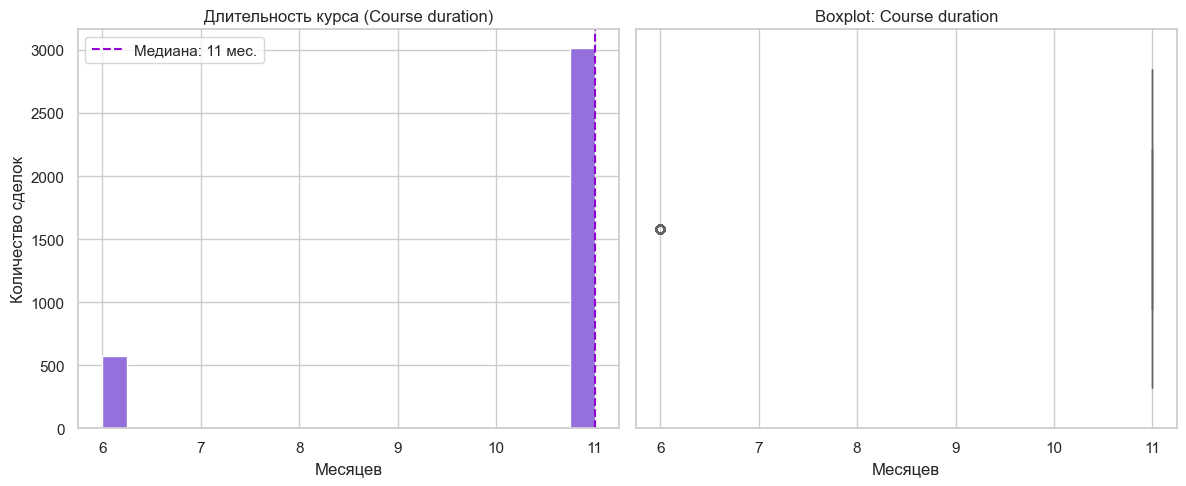

IQR диапазон: 11 – 11 мес.  (IQR = 0)
Выбросов: 575 (порог: < 11 или > 11 мес.)


In [17]:
cd = deals['Course duration'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(cd, bins=20, color='mediumpurple', edgecolor='white')
axes[0].set_title('Длительность курса (Course duration)')
axes[0].set_xlabel('Месяцев')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(cd.median(), color='darkviolet', linestyle='--',
                label=f'Медиана: {cd.median():.0f} мес.')
axes[0].legend()

sns.boxplot(x=cd, ax=axes[1], color='mediumpurple')
axes[1].set_title('Boxplot: Course duration')
axes[1].set_xlabel('Месяцев')

plt.tight_layout()
plt.show()

# IQR — выбросы
q1, q3 = cd.quantile(0.25), cd.quantile(0.75)
iqr = q3 - q1
outliers = cd[(cd < q1 - 1.5 * iqr) | (cd > q3 + 1.5 * iqr)]
print(f'IQR диапазон: {q1:.0f} – {q3:.0f} мес.  (IQR = {iqr:.0f})')
print(f'Выбросов: {len(outliers)} (порог: < {q1-1.5*iqr:.0f} или > {q3+1.5*iqr:.0f} мес.)')

### 3.5 Месяцев обучения (Months of study)

`Months of study` — сколько месяцев студент уже учится на момент выгрузки.

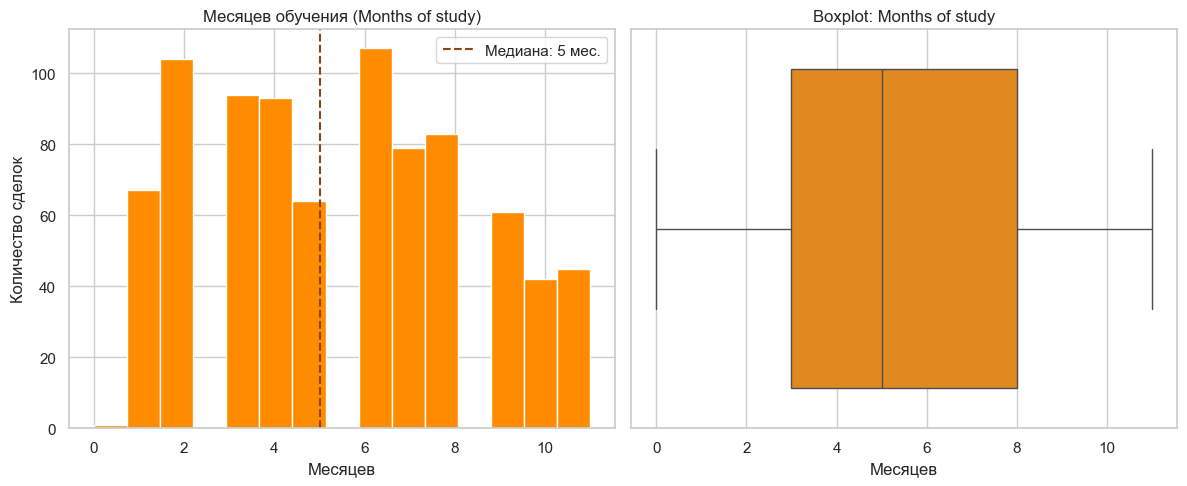

IQR диапазон: 3 – 8 мес.  (IQR = 5)
Выбросов: 0 (порог: < -4 или > 16 мес.)


In [18]:
mos = deals['Months of study'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(mos, bins=15, color='darkorange', edgecolor='white')
axes[0].set_title('Месяцев обучения (Months of study)')
axes[0].set_xlabel('Месяцев')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(mos.median(), color='saddlebrown', linestyle='--',
                label=f'Медиана: {mos.median():.0f} мес.')
axes[0].legend()

sns.boxplot(x=mos, ax=axes[1], color='darkorange')
axes[1].set_title('Boxplot: Months of study')
axes[1].set_xlabel('Месяцев')

plt.tight_layout()
plt.show()

# IQR — выбросы
q1, q3 = mos.quantile(0.25), mos.quantile(0.75)
iqr = q3 - q1
outliers = mos[(mos < q1 - 1.5 * iqr) | (mos > q3 + 1.5 * iqr)]
print(f'IQR диапазон: {q1:.0f} – {q3:.0f} мес.  (IQR = {iqr:.0f})')
print(f'Выбросов: {len(outliers)} (порог: < {q1-1.5*iqr:.0f} или > {q3+1.5*iqr:.0f} мес.)')

## 4. Категориальные переменные Deals

Анализируем ключевые поля воронки продаж:
**Stage, Quality, Source, Product, Education Type, Payment Type**.


### 4.1 Стадии сделок (Stage)

In [19]:
# value_counts показывает абсолютное и относительное распределение
stage_counts = deals['Stage'].value_counts()
stage_pct = deals['Stage'].value_counts(normalize=True).mul(100).round(1)

stage_df = pd.DataFrame({'Количество': stage_counts, '%': stage_pct})
print(stage_df)


                           Количество     %
Stage                                      
Lost                            15743  72.9
Call Delayed                     2248  10.4
Registered on Webinar            2072   9.6
Payment Done                      858   4.0
Waiting For Payment               325   1.5
Qualificated                      128   0.6
Registered on Offline Day         100   0.5
Need to Call - Sales               33   0.2
Need To Call                       31   0.1
Test Sent                          25   0.1
Need a consultation                23   0.1
New Lead                            6   0.0
Free Education                      1   0.0


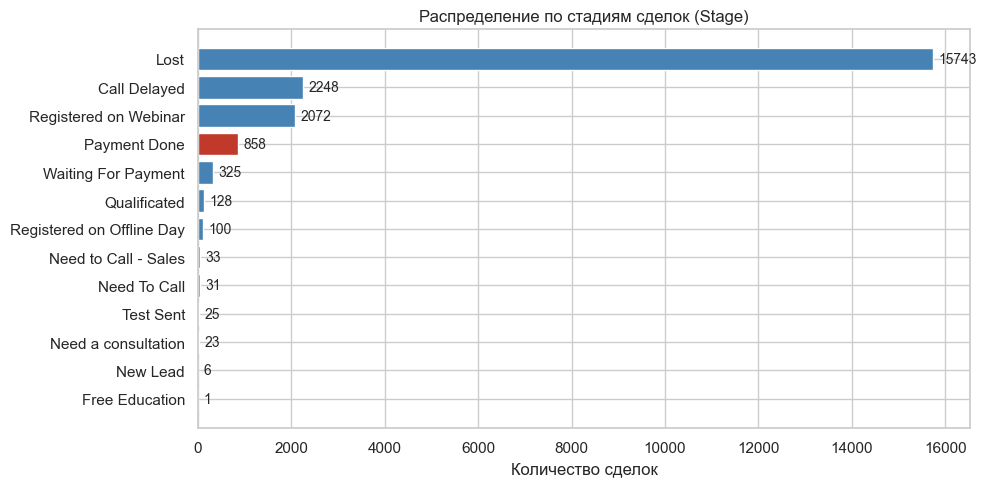

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

# Горизонтальный барчарт — хорошо читается при длинных лейблах
colors = ['#c0392b' if s == 'Payment Done' else 'steelblue'
          for s in stage_counts.index]
bars = ax.barh(stage_counts.index[::-1], stage_counts.values[::-1],
               color=colors[::-1])

ax.set_title('Распределение по стадиям сделок (Stage)')
ax.set_xlabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4, fontsize=10)

plt.tight_layout()
plt.savefig('../data_clean/plots/stage_distribution.png', dpi=100)
plt.show()


In [21]:
# Воронка: ключевые коэффициенты конверсии
total = len(deals)
payment_done = (deals['Stage'] == 'Payment Done').sum()
lost = (deals['Stage'] == 'Lost').sum()

print(f'Всего сделок:         {total}')
print(f'Оплачено (Payment Done): {payment_done} ({payment_done/total:.1%})')
print(f'Потеряно (Lost):         {lost} ({lost/total:.1%})')
print()
print('Вывод: конверсия в оплату ~4% — это низкий показатель.')
print('73% сделок закрыты как Lost — основной объект для анализа причин.')


Всего сделок:         21593
Оплачено (Payment Done): 858 (4.0%)
Потеряно (Lost):         15743 (72.9%)

Вывод: конверсия в оплату ~4% — это низкий показатель.
73% сделок закрыты как Lost — основной объект для анализа причин.


### 4.2 Качество лидов (Quality)

In [22]:
# Задаём правильный порядок — от наилучшего к наихудшему
quality_order = ['A - High', 'B - Medium', 'C - Low',
                 'D - Non Target', 'E - Non Qualified']

quality_counts = deals['Quality'].value_counts().reindex(quality_order)
print(quality_counts)


Quality
A - High              432
B - Medium           1564
C - Low              3459
D - Non Target       6248
E - Non Qualified    7634
Name: count, dtype: int64


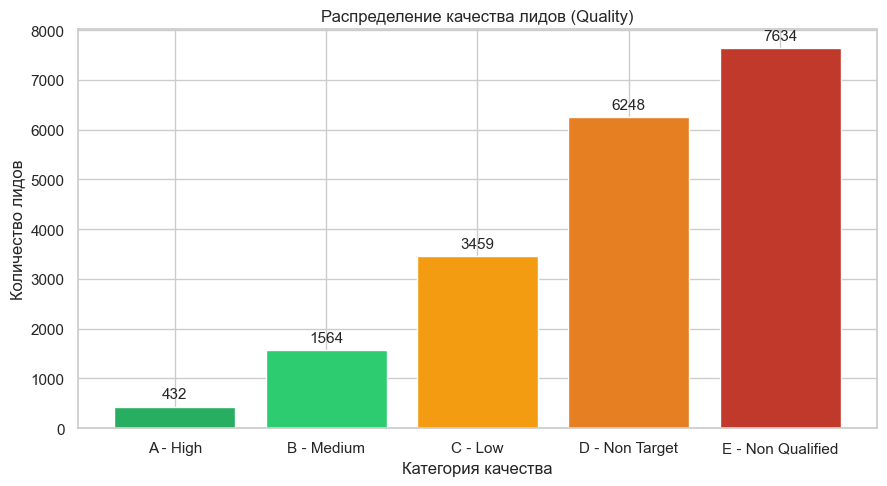

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

palette = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#c0392b']
bars = ax.bar(quality_order, quality_counts.values, color=palette)
ax.set_title('Распределение качества лидов (Quality)')
ax.set_xlabel('Категория качества')
ax.set_ylabel('Количество лидов')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/quality_distribution.png', dpi=100)
plt.show()


In [24]:
# Какова конверсия по каждому уровню качества?
quality_conv = (
    deals[deals['Quality'].notna()]
    .groupby('Quality')['Stage']
    .apply(lambda x: (x == 'Payment Done').sum() / len(x))
    .reindex(quality_order)
    .mul(100)
    .round(1)
)

print('Конверсия в оплату по качеству лида (%):')
print(quality_conv)


Конверсия в оплату по качеству лида (%):
Quality
A - High             33.1
B - Medium           20.9
C - Low              10.3
D - Non Target        0.5
E - Non Qualified     0.0
Name: Stage, dtype: float64


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_37972\2243064081.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Quality')['Stage']


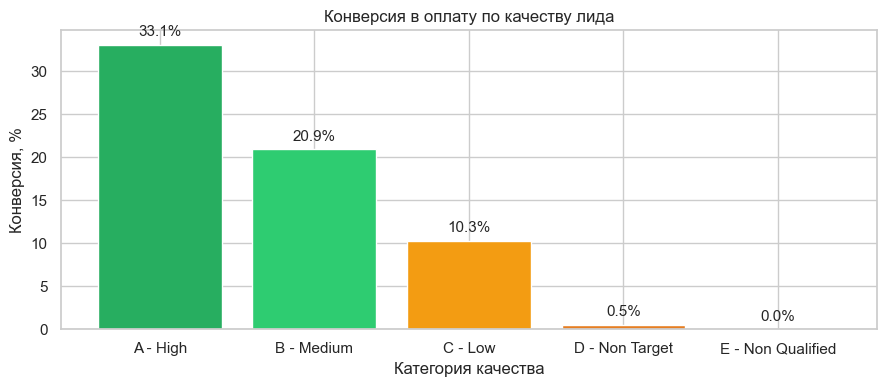

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(quality_conv.index, quality_conv.values, color=palette)
ax.set_title('Конверсия в оплату по качеству лида')
ax.set_xlabel('Категория качества')
ax.set_ylabel('Конверсия, %')
ax.bar_label(bars, fmt='%.1f%%', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/quality_conversion.png', dpi=100)
plt.show()


In [26]:
print('Вывод: лиды категории A и B конвертируются значительно лучше.')
print('Большинство лидов — категории D и E (нецелевые/неквалифицированные),')
print('что объясняет низкую общую конверсию ~4%.')


Вывод: лиды категории A и B конвертируются значительно лучше.
Большинство лидов — категории D и E (нецелевые/неквалифицированные),
что объясняет низкую общую конверсию ~4%.


### 4.3 Источники трафика (Source)

In [27]:
source_counts = deals['Source'].value_counts()
source_pct = deals['Source'].value_counts(normalize=True).mul(100).round(1)

src_df = pd.DataFrame({'Лидов': source_counts, '%': source_pct})
print(src_df.head(12))


                Лидов     %
Source                     
Facebook Ads     4850  22.5
Google Ads       4226  19.6
Organic          2590  12.0
Tiktok Ads       2051   9.5
SMM              1730   8.0
Youtube Ads      1657   7.7
CRM              1656   7.7
Bloggers         1089   5.0
Telegram posts   1001   4.6
Webinar           379   1.8
Partnership       203   0.9
Test              159   0.7


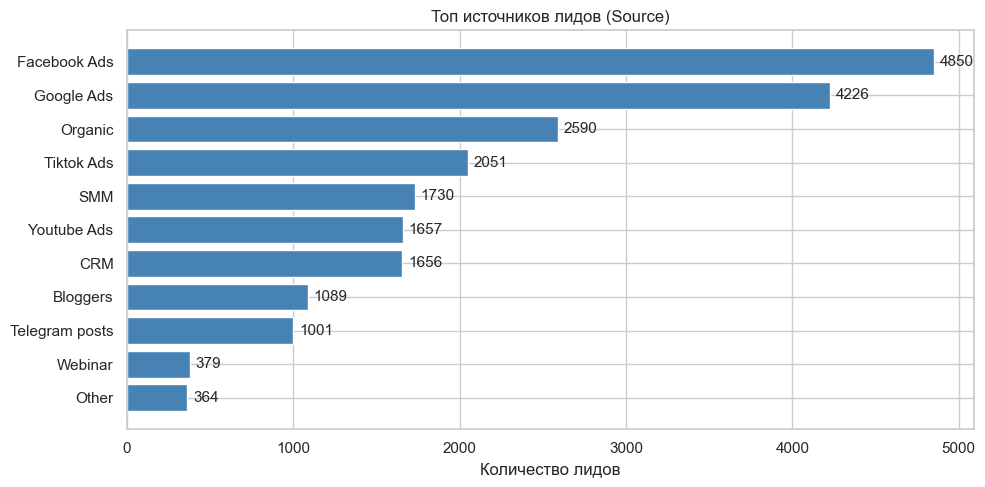

In [28]:
# Топ-10 источников — остальные объединяем в «Other»
top_sources = source_counts.head(10)
other_count = source_counts.iloc[10:].sum()
if other_count > 0:
    top_sources = pd.concat([top_sources,
                             pd.Series({'Other': other_count})])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_sources.index[::-1], top_sources.values[::-1],
               color='steelblue')
ax.set_title('Топ источников лидов (Source)')
ax.set_xlabel('Количество лидов')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/source_distribution.png', dpi=100)
plt.show()


In [29]:
# Конверсия по источникам — сколько оплат из каждого источника
source_conv = (
    deals.groupby('Source')['Stage']
    .apply(lambda x: (x == 'Payment Done').sum() / len(x))
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print('Конверсия в оплату по источнику (%):')
print(source_conv)


Конверсия в оплату по источнику (%):
Source
Webinar           6.86
Organic           5.68
SMM               5.26
Facebook Ads      4.16
Google Ads        4.09
Telegram posts    4.00
Bloggers          3.58
Youtube Ads       3.20
Tiktok Ads        2.73
Partnership       1.97
Test              1.89
CRM               1.45
Offline           0.00
Name: Stage, dtype: float64


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_37972\411588843.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deals.groupby('Source')['Stage']


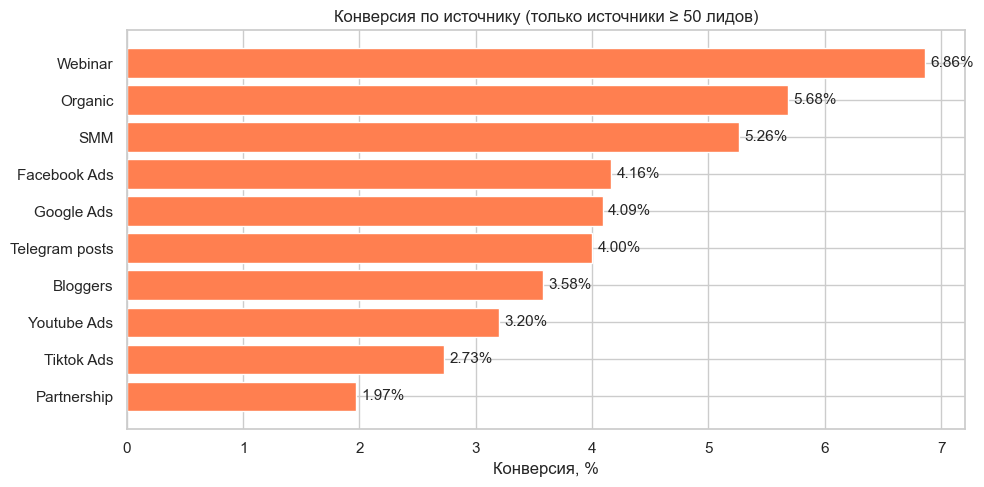

In [30]:
# График топ-10 по конверсии (только источники с ≥ 50 лидами)
source_size = deals['Source'].value_counts()
large_sources = source_size[source_size >= 50].index

source_conv_filtered = source_conv.loc[
    source_conv.index.isin(large_sources)
].head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(source_conv_filtered.index[::-1],
               source_conv_filtered.values[::-1], color='coral')
ax.set_title('Конверсия по источнику (только источники ≥ 50 лидов)')
ax.set_xlabel('Конверсия, %')
ax.bar_label(bars, fmt='%.2f%%', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/source_conversion.png', dpi=100)
plt.show()


### 4.4 Продукты (Product)

In [31]:
# Product заполнен только на поздних стадиях воронки
product_counts = deals['Product'].value_counts()
print('Распределение по продуктам (только у сделок с известным продуктом):')
print(product_counts)
print(f'\nДоля сделок с заполненным Product: '
      f'{deals["Product"].notna().sum()} из {len(deals)} '
      f'({deals["Product"].notna().mean():.1%})')


Распределение по продуктам (только у сделок с известным продуктом):
Product
Digital Marketing      1990
UX/UI Design           1022
Web Developer           575
Find yourself in IT       4
Data Analytics            1
Name: count, dtype: int64

Доля сделок с заполненным Product: 3592 из 21593 (16.6%)


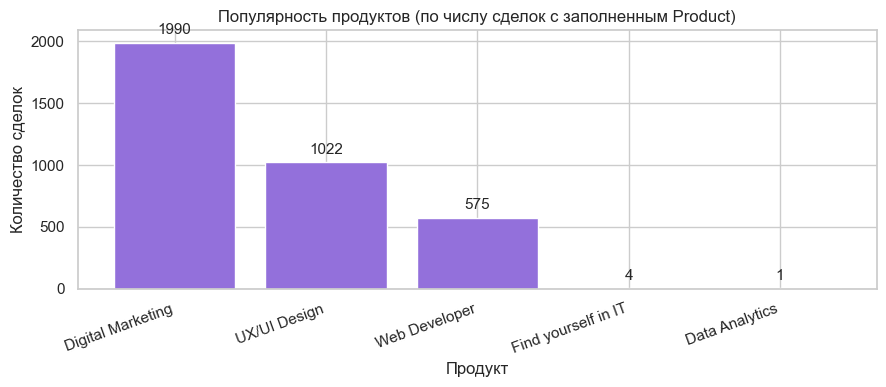

In [32]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(product_counts.index, product_counts.values, color='mediumpurple')
ax.set_title('Популярность продуктов (по числу сделок с заполненным Product)')
ax.set_xlabel('Продукт')
ax.set_ylabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4)
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig('../data_clean/plots/product_distribution.png', dpi=100)
plt.show()


In [33]:
print('Вывод: Digital Marketing — самый популярный продукт (почти 2/3 сделок).')
print('UX/UI Design и Web Developer — значительно меньше.')
print('Find yourself in IT и Data Analytics — единицы: нишевые или новые продукты.')


Вывод: Digital Marketing — самый популярный продукт (почти 2/3 сделок).
UX/UI Design и Web Developer — значительно меньше.
Find yourself in IT и Data Analytics — единицы: нишевые или новые продукты.


### 4.5 Тип образования (Education Type)

In [34]:
edu_counts = deals['Education Type'].value_counts(dropna=False)
print(edu_counts)


Education Type
NaN        18294
Morning     2895
Evening      404
Name: count, dtype: int64


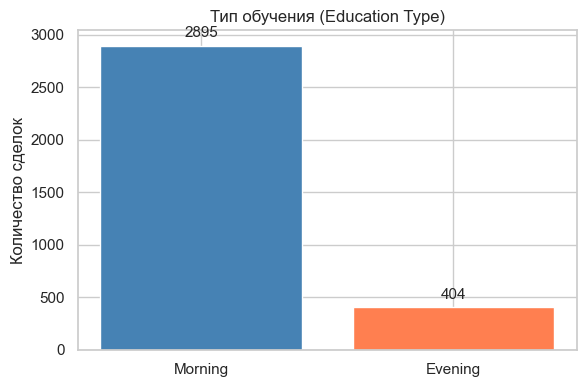

In [35]:
# Строим диаграмму только по известным значениям
edu_known = deals['Education Type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(edu_known.index, edu_known.values, color=['steelblue', 'coral'])
ax.set_title('Тип обучения (Education Type)')
ax.set_ylabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/education_type.png', dpi=100)
plt.show()


### 4.6 Тип платежа (Payment Type)

In [36]:
# Payment Type заполнен только у оплативших — 858 строк
payment_counts = deals['Payment Type'].value_counts(dropna=False)
print('Payment Type (всего строк с оплатой):')
print(payment_counts)


Payment Type (всего строк с оплатой):
Payment Type
NaN                   21097
Recurring Payments      350
One Payment             141
Reservation               5
Name: count, dtype: int64


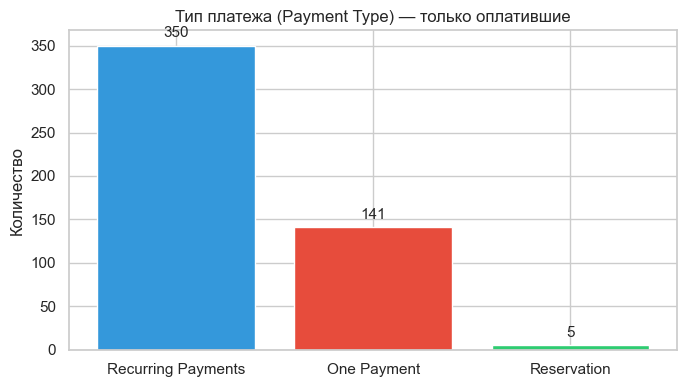

In [37]:
payment_known = deals['Payment Type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(payment_known.index, payment_known.values,
              color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_title('Тип платежа (Payment Type) — только оплатившие')
ax.set_ylabel('Количество')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/payment_type.png', dpi=100)
plt.show()


In [38]:
print('Вывод: рассрочка (Recurring Payments) — самый распространённый тип оплаты.')
print('Единоразовая оплата (One Payment) — второй по популярности.')
print('Бронирование (Reservation) — единицы: используется как аванс/резерв места.')


Вывод: рассрочка (Recurring Payments) — самый распространённый тип оплаты.
Единоразовая оплата (One Payment) — второй по популярности.
Бронирование (Reservation) — единицы: используется как аванс/резерв места.


### 4.7 Менеджеры по продажам (Deal Owner Name)

Анализируем распределение сделок по менеджерам и их результативность.

In [ ]:
# Топ-15 менеджеров по количеству сделок
owner_counts = deals['Deal Owner Name'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

owner_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Топ-15 менеджеров — количество сделок')
axes[0].set_xlabel('Менеджер')
axes[0].set_ylabel('Количество сделок')
axes[0].tick_params(axis='x', rotation=45)

# Конверсия по менеджерам (доля Payment Done)
owner_conv = (
    deals.groupby('Deal Owner Name')['Stage']
    .apply(lambda x: (x == 'Payment Done').sum() / len(x))
    .sort_values(ascending=False)
    .head(15)
)
owner_conv.plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Топ-15 менеджеров — конверсия в оплату')
axes[1].set_xlabel('Менеджер')
axes[1].set_ylabel('Доля Payment Done')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

### 4.8 Уровень немецкого (Level of Deutsch)

Уровень немецкого языка может влиять на конверсию — проверяем распределение.

In [ ]:
# Level of Deutsch: распределение по уровням
deutsch_counts = deals['Level of Deutsch'].value_counts(dropna=False)
print('Распределение по уровням немецкого:')
print(deutsch_counts)
print(f'\nПропущено: {deals["Level of Deutsch"].isna().sum()} ({deals["Level of Deutsch"].isna().mean():.1%})')

known = deals['Level of Deutsch'].dropna()
if len(known) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    known.value_counts().plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Уровень немецкого (Level of Deutsch)')
    ax.set_xlabel('Уровень')
    ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

### 4.9 Кампании (Campaign)

Топ рекламных кампаний по количеству привлечённых лидов.

In [ ]:
# Топ-15 кампаний по количеству сделок
campaign_counts = deals['Campaign'].value_counts().head(15)
print(campaign_counts)

fig, ax = plt.subplots(figsize=(12, 5))
campaign_counts.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Топ-15 кампаний — количество сделок')
ax.set_xlabel('Кампания')
ax.set_ylabel('Количество')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 4.10 Причины отказа (Lost Reason)

Анализируем только сделки со статусом Lost.

In [ ]:
# Lost Reason — только для потерянных сделок
lost = deals[deals['Stage'] == 'Lost']
lost_reasons = lost['Lost Reason'].value_counts(dropna=False)
print(f'Всего потерянных сделок: {len(lost)}')
print(f'Причина указана: {lost["Lost Reason"].notna().sum()} ({lost["Lost Reason"].notna().mean():.1%})')
print()
print(lost_reasons.head(15))

### 4.11 Города (City)

Географическое распределение лидов. Важно: 88% значений отсутствует.

In [ ]:
# City: топ-10 городов (из тех, где данные есть)
city_total = deals['City'].notna().sum()
city_pct = city_total / len(deals)
print(f'Заполнено: {city_total} из {len(deals)} ({city_pct:.1%})')
print(f'Пропущено: {deals["City"].isna().sum()} ({deals["City"].isna().mean():.1%})')
print()

city_counts = deals['City'].value_counts().head(10)
print('Топ-10 городов:')
print(city_counts)

fig, ax = plt.subplots(figsize=(10, 4))
city_counts.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Топ-10 городов (из заполненных)')
ax.set_xlabel('Город')
ax.set_ylabel('Количество')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 4.12 Флаги аномалий (closing_date_error, amount_error)

Флаги выявлены при очистке данных — проверяем масштаб проблемы.

In [ ]:
# Флаги аномалий из этапа очистки
date_err = deals['closing_date_error'].sum()
amt_err  = deals['amount_error'].sum()
total    = len(deals)

print(f'closing_date_error (дата закрытия < дата создания): {date_err} ({date_err/total:.2%})')
print(f'amount_error (IAP > OTA):                           {amt_err} ({amt_err/total:.2%})')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Норма', 'Ошибка дат'],
            [total - date_err, date_err],
            color=['steelblue', 'tomato'])
axes[0].set_title('closing_date_error')
axes[0].set_ylabel('Количество сделок')

axes[1].bar(['Норма', 'Ошибка суммы'],
            [total - amt_err, amt_err],
            color=['steelblue', 'tomato'])
axes[1].set_title('amount_error')

plt.tight_layout()
plt.show()

## 5. Двумерный анализ числовых переменных (Deals)

Парный график показывает линейную зависимость между всеми парами числовых переменных.

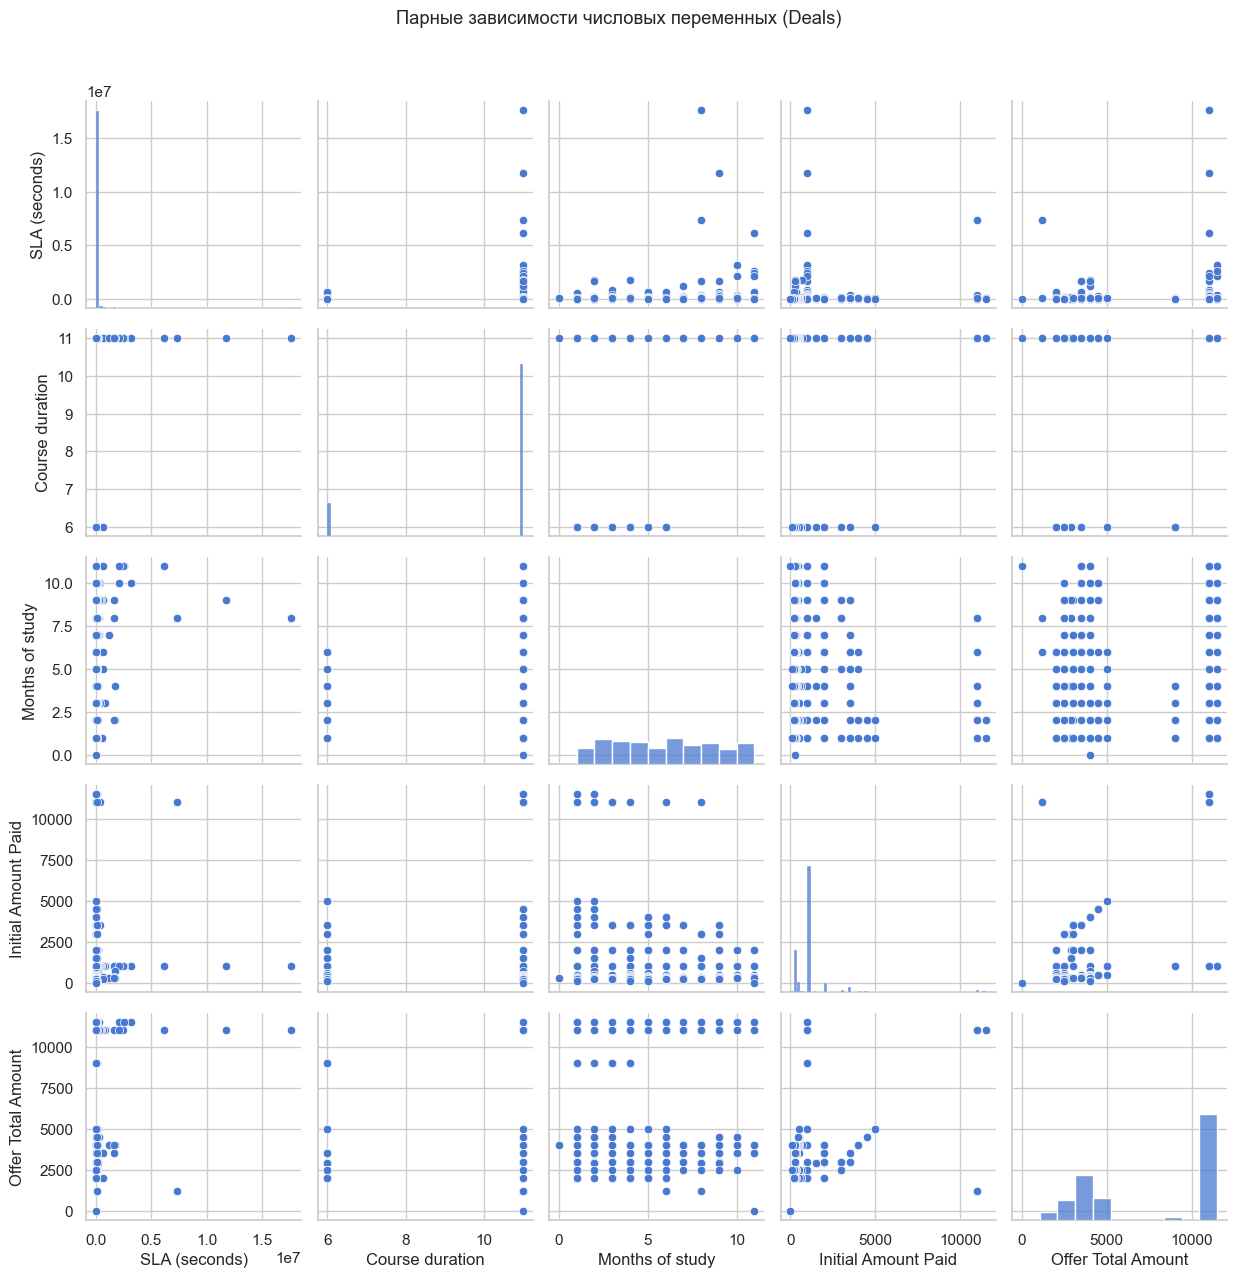

In [39]:
# Парный график (pairplot) для числовых полей Deals
# Каждая ячейка — scatter plot двух переменных, диагональ — распределение
num_deals = ['SLA (seconds)', 'Course duration', 'Months of study',
             'Initial Amount Paid', 'Offer Total Amount']

sns.pairplot(deals[num_deals].dropna())
plt.suptitle('Парные зависимости числовых переменных (Deals)', y=1.02)
plt.tight_layout()
plt.show()

**Вывод:** парный график помогает увидеть, какие переменные коррелируют между собой.

## 6. Многомерный анализ (Deals)

Тепловая карта корреляций — значения от -1 до 1: ближе к 1 = сильная прямая связь, ближе к -1 = обратная, около 0 = нет связи.

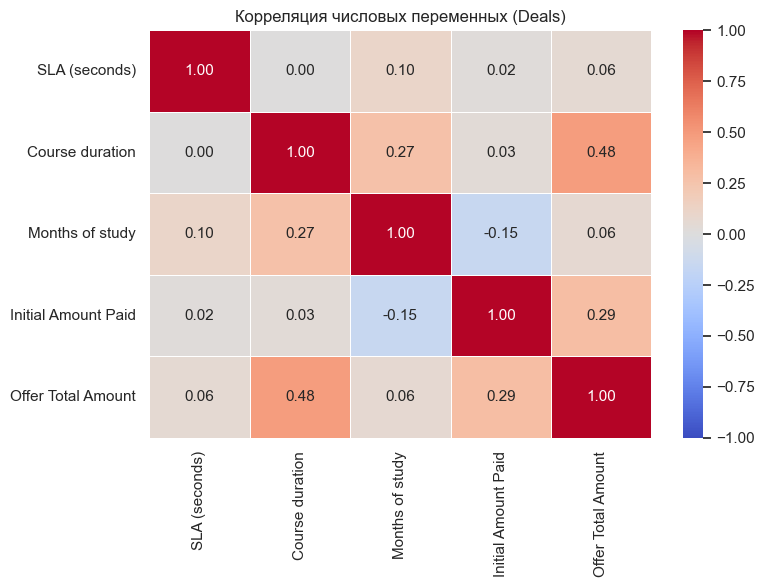

In [40]:
# Тепловая карта корреляций числовых полей Deals
# annot=True — показывает числа прямо на карте
plt.figure(figsize=(8, 6))

sns.heatmap(
    deals[num_deals].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Корреляция числовых переменных (Deals)')
plt.tight_layout()
plt.show()

**Вывод:** тепловая карта показывает все попарные корреляции числовых переменных сразу.

## 7. Анализ звонков (Calls)

### 7.1 Типы звонков

In [41]:
call_type_counts = calls['Call Type'].value_counts()
print(call_type_counts)
print()
print(f'Доля исходящих (Outbound): {call_type_counts.get("Outbound", 0) / len(calls):.1%}')


Call Type
Outbound    86875
Missed       5921
Inbound      3078
Name: count, dtype: int64

Доля исходящих (Outbound): 90.6%


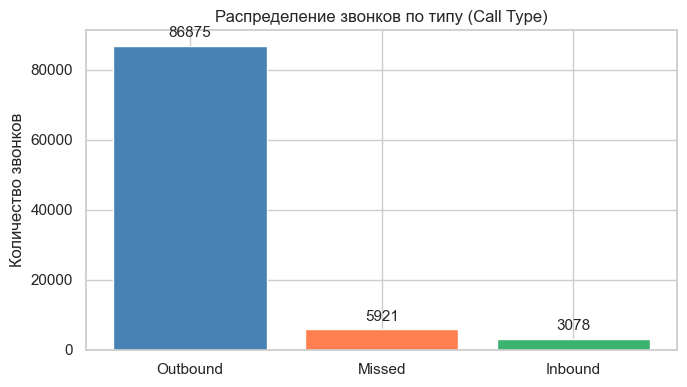

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['steelblue', 'coral', 'mediumseagreen']
bars = ax.bar(call_type_counts.index, call_type_counts.values, color=colors)
ax.set_title('Распределение звонков по типу (Call Type)')
ax.set_ylabel('Количество звонков')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/call_type.png', dpi=100)
plt.show()


### 7.2 Длительность звонков (Call Duration)

In [43]:
# Call Duration в секундах — конвертируем в минуты
# Смотрим только на исходящие завершённые звонки (Outbound)
duration_sec = calls.loc[
    (calls['Call Type'] == 'Outbound') & calls['Call Duration (in seconds)'].notna(),
    'Call Duration (in seconds)'
]
duration_min = duration_sec / 60

print(f'Исходящих звонков с длительностью: {len(duration_min)}')
print(f'Среднее:  {duration_min.mean():.1f} мин')
print(f'Медиана:  {duration_min.median():.1f} мин')
print(f'Q1:       {duration_min.quantile(0.25):.1f} мин')
print(f'Q3:       {duration_min.quantile(0.75):.1f} мин')
print(f'Макс:     {duration_min.max():.1f} мин')


Исходящих звонков с длительностью: 86792
Среднее:  2.8 мин
Медиана:  0.1 мин
Q1:       0.1 мин
Q3:       1.7 мин
Макс:     127.1 мин


In [44]:
# Ограничиваем до 30 минут — крайние выбросы искажают картину
duration_trimmed = duration_min[duration_min <= 30]
print(f'Звонков ≤ 30 мин: {len(duration_trimmed)} '
      f'({len(duration_trimmed)/len(duration_min):.1%} от всех)')


Звонков ≤ 30 мин: 85458 (98.5% от всех)


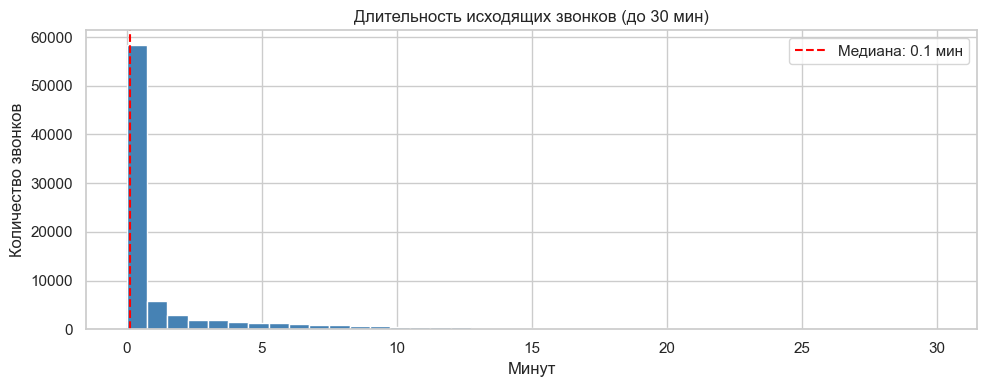

In [45]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(duration_trimmed, bins=40, color='steelblue', edgecolor='white')
ax.set_title('Длительность исходящих звонков (до 30 мин)')
ax.set_xlabel('Минут')
ax.set_ylabel('Количество звонков')
ax.axvline(duration_trimmed.median(), color='red', linestyle='--',
           label=f'Медиана: {duration_trimmed.median():.1f} мин')
ax.legend()

plt.tight_layout()
plt.savefig('../data_clean/plots/call_duration.png', dpi=100)
plt.show()


In [46]:
# Доля очень коротких звонков — вероятно, недозвоны
short_calls = (duration_min <= 0.5).sum()  # ≤ 30 секунд
print(f'Звонков ≤ 30 сек (вероятно, недозвоны): '
      f'{short_calls} ({short_calls/len(duration_min):.1%})')
print()
print('Вывод: типичный разговор ~4-5 мин; значительная доля звонков очень короткие.')
print('Это означает, что часть исходящих — недозвоны или отказы с порога.')


Звонков ≤ 30 сек (вероятно, недозвоны): 55382 (63.8%)

Вывод: типичный разговор ~4-5 мин; значительная доля звонков очень короткие.
Это означает, что часть исходящих — недозвоны или отказы с порога.


### 7.3 Статус исходящих звонков

In [47]:
# Outgoing Call Status — заполнен только для исходящих звонков
outbound_status = calls.loc[
    calls['Call Type'] == 'Outbound',
    'Outgoing Call Status'
].value_counts(dropna=False)

print('Статус исходящих звонков:')
print(outbound_status)


Статус исходящих звонков:
Outgoing Call Status
Completed    86792
Overdue         60
Cancelled       20
Scheduled        3
Name: count, dtype: int64


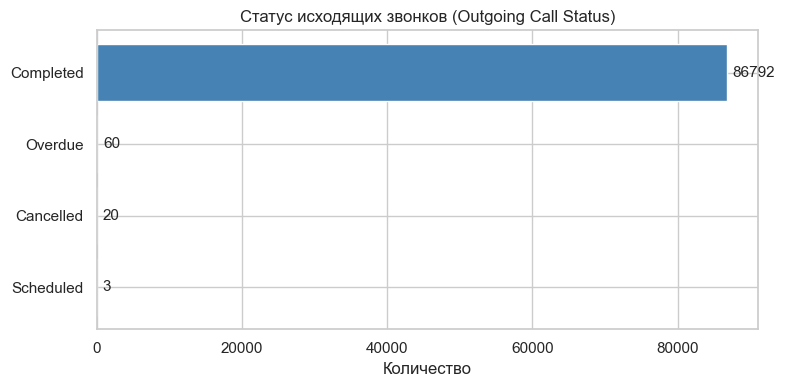

In [48]:
status_known = calls.loc[
    (calls['Call Type'] == 'Outbound') & calls['Outgoing Call Status'].notna(),
    'Outgoing Call Status'
].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(status_known.index[::-1], status_known.values[::-1],
               color='steelblue')
ax.set_title('Статус исходящих звонков (Outgoing Call Status)')
ax.set_xlabel('Количество')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/call_status.png', dpi=100)
plt.show()


### 7.4 Статус звонка (Call Status)

Общий результат звонка — включая входящие и исходящие.

In [ ]:
# Call Status — результат звонка для всех типов
status_counts = calls['Call Status'].value_counts()
print(status_counts)

fig, ax = plt.subplots(figsize=(10, 4))
status_counts.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Call Status — результат звонка')
ax.set_xlabel('Статус')
ax.set_ylabel('Количество звонков')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 7.5 Менеджеры звонков (Call Owner Name)

Распределение звонков по сотрудникам.

In [ ]:
# Топ-15 менеджеров по количеству звонков
call_owner = calls['Call Owner Name'].value_counts().head(15)
print(call_owner)

fig, ax = plt.subplots(figsize=(12, 4))
call_owner.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Топ-15 менеджеров — количество звонков')
ax.set_xlabel('Менеджер')
ax.set_ylabel('Количество звонков')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Средняя длительность звонка по менеджеру (двумерный: категория × число)
avg_dur = (
    calls.groupby('Call Owner Name')['Call Duration (in seconds)']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    / 60  # в минуты
)
fig, ax = plt.subplots(figsize=(12, 4))
avg_dur.plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Средняя длительность звонка по менеджеру (мин)')
ax.set_xlabel('Менеджер')
ax.set_ylabel('Минут')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 7.6 Запланированные звонки (Scheduled in CRM)

Показывает, был ли звонок запланирован заранее (1) или нет (0).

In [ ]:
# Scheduled in CRM: 0 = не запланирован, 1 = запланирован
sched = calls['Scheduled in CRM'].value_counts(dropna=False)
print(sched)
scheduled_pct = (calls['Scheduled in CRM'] == 1).sum() / len(calls)
print(f'\nДоля запланированных: {scheduled_pct:.1%}')

## 8. Маркетинговые расходы (Spend)

Spend — данные о расходах, кликах и показах по каналам.
Анализируем распределение расходов и эффективность по источникам.


In [49]:
# Числовая статистика по Spend
spend_nums = ['Spend', 'Clicks', 'Impressions']
print(spend[spend_nums].describe().round(2))


          Spend    Clicks  Impressions
count  19862.00  19862.00     19862.00
mean       7.53     25.10      2571.70
std       27.33     87.03     11691.23
min        0.00      0.00         0.00
25%        0.00      0.00         1.00
50%        0.74      2.00        82.00
75%        6.16     13.00       760.75
max      774.00   2415.00    431445.00


In [50]:
# Итоговые суммы за весь период
print('Итого за период (июль 2023 – июнь 2024):')
print(f'  Расходы (Spend):      {spend["Spend"].sum():,.0f} €')
print(f'  Клики (Clicks):       {spend["Clicks"].sum():,.0f}')
print(f'  Показы (Impressions): {spend["Impressions"].sum():,.0f}')


Итого за период (июль 2023 – июнь 2024):
  Расходы (Spend):      149,523 €
  Клики (Clicks):       498,455
  Показы (Impressions): 51,079,010


In [51]:
# Расходы по каналам — агрегируем по Source
spend_by_source = (
    spend.groupby('Source')['Spend']
    .sum()
    .sort_values(ascending=False)
)

print('Расходы по каналам (€):')
print(spend_by_source)


Расходы по каналам (€):
Source
Google Ads        57798.60
Facebook Ads      33754.72
Youtube Ads       14633.33
Bloggers          13439.00
Tiktok Ads        11985.67
SMM                7269.52
Telegram posts     6860.36
Webinar            2874.04
Test                608.21
Radio               300.00
Organic               0.00
Offline               0.00
CRM                   0.00
Partnership           0.00
Name: Spend, dtype: float64


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_37972\1570164681.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spend.groupby('Source')['Spend']


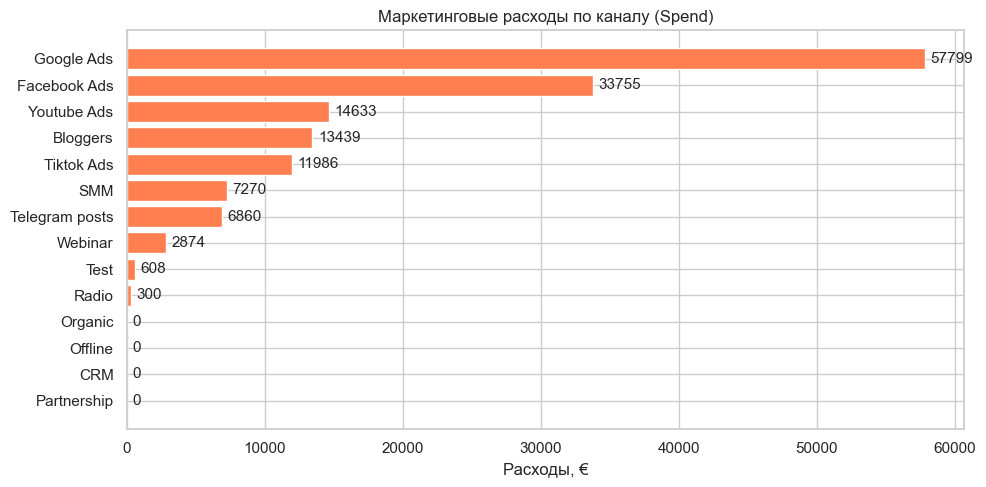

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(spend_by_source.index[::-1], spend_by_source.values[::-1],
               color='coral')
ax.set_title('Маркетинговые расходы по каналу (Spend)')
ax.set_xlabel('Расходы, €')
ax.bar_label(bars, fmt='%.0f', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/spend_by_source.png', dpi=100)
plt.show()


In [53]:
# CTR (Click-Through Rate) = Clicks / Impressions — эффективность объявлений
spend_summary = spend.groupby('Source').agg(
    total_spend=('Spend', 'sum'),
    total_clicks=('Clicks', 'sum'),
    total_impressions=('Impressions', 'sum')
).reset_index()

spend_summary['CTR'] = (
    spend_summary['total_clicks'] / spend_summary['total_impressions']
).round(4)

spend_summary['CPC'] = (
    spend_summary['total_spend'] / spend_summary['total_clicks'].replace(0, np.nan)
).round(2)

print(spend_summary[['Source', 'total_spend', 'total_clicks',
                      'CTR', 'CPC']].sort_values('total_spend', ascending=False)
      .to_string(index=False))


        Source  total_spend  total_clicks    CTR  CPC
    Google Ads     57798.60        248487 0.0076 0.23
  Facebook Ads     33754.72         48133 0.0169 0.70
   Youtube Ads     14633.33         59061 0.0068 0.25
      Bloggers     13439.00         14250 0.0193 0.94
    Tiktok Ads     11985.67         28268 0.0056 0.42
           SMM      7269.52         11521 0.4846 0.63
Telegram posts      6860.36         16777 0.0238 0.41
       Webinar      2874.04          3241 0.0107 0.89
          Test       608.21          1226 0.0279 0.50
         Radio       300.00             0    NaN  NaN
       Organic         0.00         59089    inf 0.00
       Offline         0.00            57    inf 0.00
           CRM         0.00          7995    inf 0.00
   Partnership         0.00           350    inf 0.00


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_37972\3201899702.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spend_summary = spend.groupby('Source').agg(


In [54]:
print('Вывод: Facebook и TikTok занимают наибольшую долю бюджета.')
print('Для оценки эффективности каналов нужно сопоставить Spend с количеством')
print('и качеством лидов — это сделаем в 03_analysis (CAC по источникам).')


Вывод: Facebook и TikTok занимают наибольшую долю бюджета.
Для оценки эффективности каналов нужно сопоставить Spend с количеством
и качеством лидов — это сделаем в 03_analysis (CAC по источникам).


### 8.5 Кампании (Campaign) в Spend

Анализируем топ кампаний по расходам.

In [ ]:
# Топ-15 кампаний по расходам
camp_spend = (
    spend.groupby('Campaign')['Spend']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
print('Топ-15 кампаний по расходам (€):')
print(camp_spend)

fig, ax = plt.subplots(figsize=(12, 5))
camp_spend.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Топ-15 кампаний по расходам')
ax.set_xlabel('Кампания')
ax.set_ylabel('Расходы, €')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 9. Таблица контактов (Contacts)

Contacts — справочная таблица с данными о контактах. Содержит: `Contact Owner Name` (менеджер), `Created Time` (дата создания).

In [ ]:
# Базовая статистика по Contacts
print(f'Всего контактов: {len(contacts)}')
print(f'Столбцы: {list(contacts.columns)}')
print(f'Пропуски:')
print(contacts.isnull().sum())

### 9.1 Менеджеры контактов (Contact Owner Name)

In [ ]:
# Распределение контактов по менеджерам
contact_owner = contacts['Contact Owner Name'].value_counts().head(15)
print(contact_owner)

fig, ax = plt.subplots(figsize=(12, 4))
contact_owner.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Топ-15 менеджеров — количество контактов')
ax.set_xlabel('Менеджер')
ax.set_ylabel('Количество контактов')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 9.2 Динамика создания контактов (Created Time)

In [ ]:
# Восстанавливаем тип даты
contacts['Created Time'] = pd.to_datetime(contacts['Created Time'])

# Группируем по месяцу
contacts_by_month = (
    contacts.set_index('Created Time')
    .resample('ME')
    .size()
)

fig, ax = plt.subplots(figsize=(12, 4))
contacts_by_month.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Новые контакты по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество контактов')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 10. Сводные выводы по описательной статистике

In [55]:
print('=== Ключевые выводы этапа 2 ===')
print()
print('ВОРОНКА ПРОДАЖ:')
print(f'  Всего сделок: {len(deals):,}')
payment_n = (deals["Stage"] == "Payment Done").sum()
lost_n = (deals["Stage"] == "Lost").sum()
print(f'  Оплачено: {payment_n} ({payment_n/len(deals):.1%})')
print(f'  Потеряно: {lost_n} ({lost_n/len(deals):.1%})')
print()
print('ФИНАНСЫ (без символических оплат 0/1/9 €):')
iap_clean = deals.loc[(~deals["Initial Amount Paid"].isin([0, 1, 9])) & deals["Initial Amount Paid"].notna(),
                      "Initial Amount Paid"]
print(f'  Медиана первого платежа: {iap_clean.median():.0f} €')
print(f'  Средний первый платёж:   {iap_clean.mean():.0f} €')
print()
print('КАЧЕСТВО ЛИДОВ:')
low_quality = deals['Quality'].isin(['D - Non Target', 'E - Non Qualified']).sum()
print(f'  D+E (нецелевые): {low_quality} ({low_quality/deals["Quality"].notna().sum():.1%})')
print()
total_spend = spend['Spend'].sum()
print(f'МАРКЕТИНГ: суммарный бюджет {total_spend:,.0f} €, '
      f'{spend["Clicks"].sum():,} кликов')


=== Ключевые выводы этапа 2 ===

ВОРОНКА ПРОДАЖ:
  Всего сделок: 21,593
  Оплачено: 858 (4.0%)
  Потеряно: 15743 (72.9%)

ФИНАНСЫ (без символических оплат 0/1/9 €):
  Медиана первого платежа: 1000 €
  Средний первый платёж:   1205 €

КАЧЕСТВО ЛИДОВ:
  D+E (нецелевые): 13882 (71.8%)

МАРКЕТИНГ: суммарный бюджет 149,523 €, 498,455 кликов


### Итого по этапу 2

| Показатель | Значение |
|---|---|
| Сделок всего | 21 593 |
| Конверсия в оплату | ~4% |
| Медиана первого платежа | ~1 000 € |
| Доля нецелевых лидов (D+E) | ~70% |
| SLA медиана | — ч (расчёт выше) |
| Звонков всего | 95 874 |
| Доля исходящих | ~91% |
| Маркетинговый бюджет | ~149 523 € |

**Главные инсайты:**
1. Конверсия 4% — низкая, главный рычаг роста — качество лидов и скорость обработки.
2. 70% лидов нецелевые (D+E) — маркетинг приводит много «мусорного» трафика.
3. Самый крупный продукт — Digital Marketing (≈60% сделок).
4. Рассрочка — доминирующая модель оплаты.
5. Facebook Ads — крупнейший канал по расходам; эффективность к числу оплат — в следующем ноутбуке.

---
*Следующий этап: `03_analysis.ipynb` — временные ряды, кампании, отдел продаж, продукты, география.*
